# OBP Empirical Bayes Analysis Template

This notebook loads pipeline outputs and builds high-value visualizations for:
- posterior OBP ranking + uncertainty
- shrinkage behavior (raw vs posterior)
- uncertainty vs sample size (PA)
- posterior correction distribution
- feature coefficient interpretation
- optional MCMC diagnostics via ArviZ

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import arviz as az
except Exception:
    az = None

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

In [9]:
# Set this to the output folder you want to analyze.
# Use "outputs" for full runs, or "outputs_smoke" for quick tests.
OUTPUT_DIR = Path("outputs_smoke")

posterior_path = OUTPUT_DIR / "obp_posterior_estimates.csv"
beta_path = OUTPUT_DIR / "beta_summary.csv"
model_summary_path = OUTPUT_DIR / "model_summary.csv"
trace_path = OUTPUT_DIR / "obp_trace.nc"

assert posterior_path.exists(), f"Missing file: {posterior_path}"
assert beta_path.exists(), f"Missing file: {beta_path}"
assert model_summary_path.exists(), f"Missing file: {model_summary_path}"

posterior = pd.read_csv(posterior_path)
beta = pd.read_csv(beta_path)
model_summary = pd.read_csv(model_summary_path)

posterior.head()

,Name,IDfg,key_mlbam,season,Team,Y,n,obp_raw,Age,SO,...,park_factor_z,k_rate_z,gb_rate_z,age_z,obp_posterior_mean,obp_posterior_median,obp_posterior_sd,obp_ci_lower,obp_ci_upper,shrinkage
0,Marcus Semien,12533,543760,2023,TEX,262.0,753.0,0.347942,32.0,110.0,...,0.0,-1.418018,0.0,0.933895,0.350521,0.349103,0.026227,0.315258,0.383636,0.930369
1,Freddie Freeman*,5361,518692,2023,LAD,299.0,730.0,0.409589,33.0,121.0,...,0.0,-1.098331,0.0,1.194152,0.413364,0.412100,0.021030,0.379762,0.449900,0.961755
2,Alex Bregman,17678,608324,2023,HOU,263.0,724.0,0.363260,29.0,87.0,...,0.0,-1.839205,0.0,0.153125,0.364002,0.361805,0.024592,0.326630,0.399197,0.985823
3,Nathaniel Lowe*,19566,663993,2023,TEX,261.0,724.0,0.360497,27.0,165.0,...,0.0,-0.088338,0.0,-0.367388,0.363582,0.360700,0.024937,0.322298,0.413985,0.937804
4,Matt Olson*,14344,621566,2023,ATL,280.0,720.0,0.388889,29.0,167.0,...,0.0,-0.022618,0.0,0.153125,0.389450,0.388895,0.028518,0.336354,0.439664,0.992804


In [10]:
print("Posterior shape:", posterior.shape)
print("Posterior columns:", posterior.columns.tolist())
print("Beta shape:", beta.shape)
print("Model summary shape:", model_summary.shape)

Posterior shape: (464, 25)
Posterior columns: ['Name', 'IDfg', 'key_mlbam', 'season', 'Team', 'Y', 'n', 'obp_raw', 'Age', 'SO', 'GB%', 'K%', 'park_factor', 'avg_fip_faced', 'avg_fip_faced_z', 'park_factor_z', 'k_rate_z', 'gb_rate_z', 'age_z', 'obp_posterior_mean', 'obp_posterior_median', 'obp_posterior_sd', 'obp_ci_lower', 'obp_ci_upper', 'shrinkage']
Beta shape: (5, 11)
Model summary shape: (6, 10)


## 1) Shrinkage Plot: Raw OBP vs Posterior Mean OBP

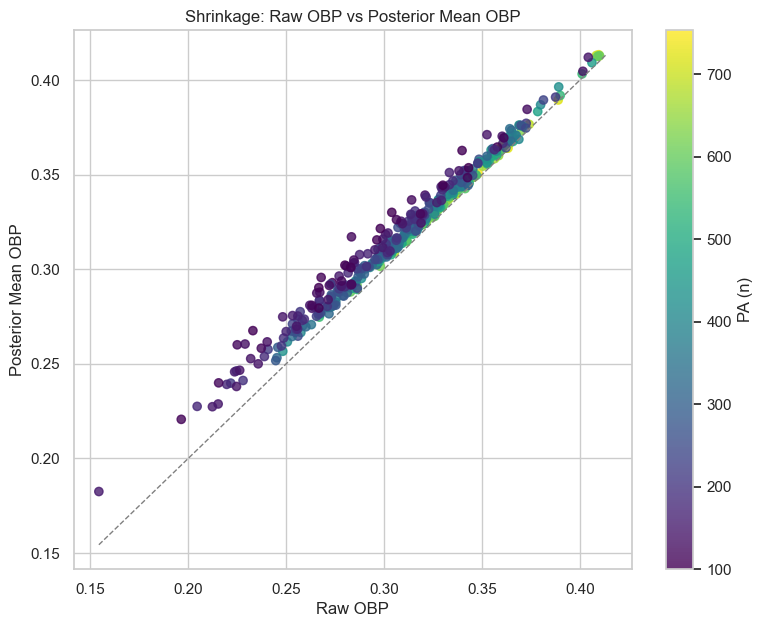

In [11]:
df = posterior.copy()
df = df.dropna(subset=["obp_raw", "obp_posterior_mean", "n"])

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    df["obp_raw"],
    df["obp_posterior_mean"],
    c=df["n"],
    cmap="viridis",
    alpha=0.8,
)
mn = min(df["obp_raw"].min(), df["obp_posterior_mean"].min())
mx = max(df["obp_raw"].max(), df["obp_posterior_mean"].max())
plt.plot([mn, mx], [mn, mx], "--", color="gray", linewidth=1)
plt.colorbar(scatter, label="PA (n)")
plt.title("Shrinkage: Raw OBP vs Posterior Mean OBP")
plt.xlabel("Raw OBP")
plt.ylabel("Posterior Mean OBP")
plt.show()

## 2) Top Posterior OBP with 95% Credible Intervals

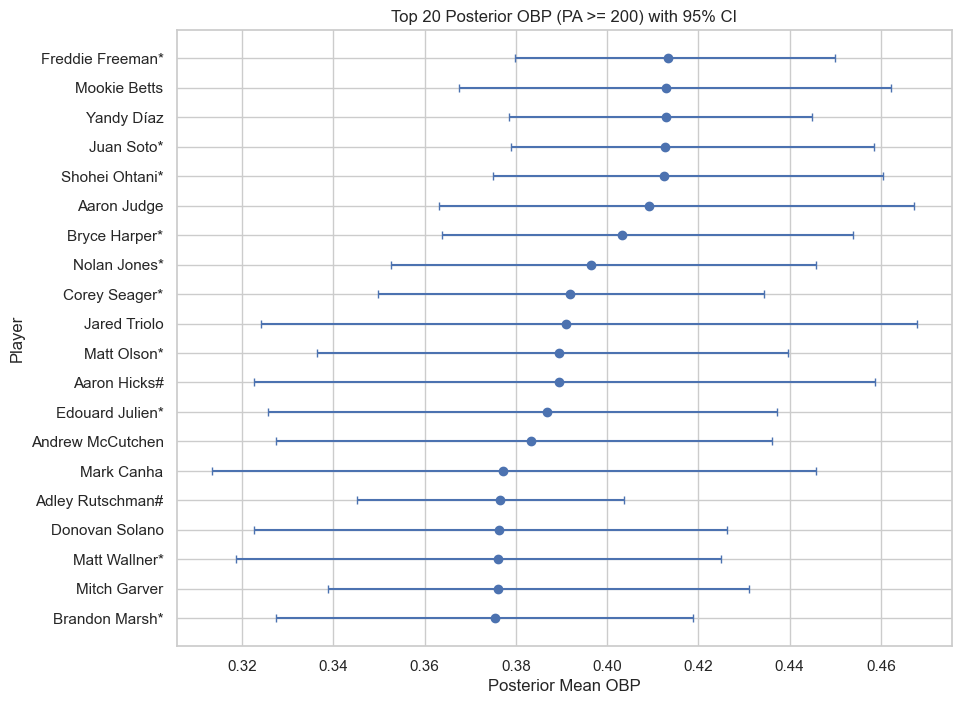

In [12]:
MIN_PA = 200
TOP_K = 20

rank_df = posterior[posterior["n"] >= MIN_PA].copy()
rank_df = rank_df.sort_values("obp_posterior_mean", ascending=False).head(TOP_K)
rank_df = rank_df.sort_values("obp_posterior_mean", ascending=True)

x = rank_df["obp_posterior_mean"]
xerr = np.vstack([
    x - rank_df["obp_ci_lower"],
    rank_df["obp_ci_upper"] - x,
])

plt.figure(figsize=(10, 8))
plt.errorbar(x=x, y=rank_df["Name"], xerr=xerr, fmt="o", capsize=3)
plt.title(f"Top {TOP_K} Posterior OBP (PA >= {MIN_PA}) with 95% CI")
plt.xlabel("Posterior Mean OBP")
plt.ylabel("Player")
plt.show()

## 3) Uncertainty vs Sample Size

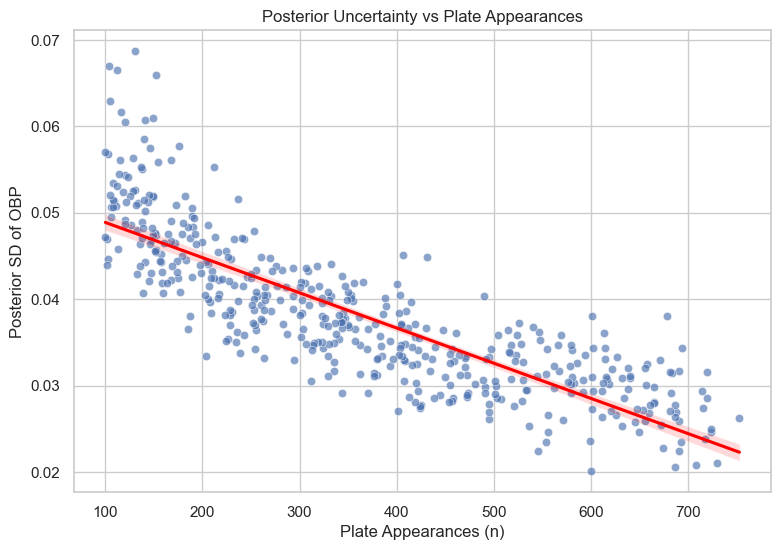

In [16]:
unc_df = posterior.dropna(subset=["n", "obp_posterior_sd"]).copy()

plt.figure(figsize=(9, 6))
sns.scatterplot(data=unc_df, x="n", y="obp_posterior_sd", alpha=0.65)
sns.regplot(data=unc_df, x="n", y="obp_posterior_sd", scatter=False, color="red")
plt.title("Posterior Uncertainty vs Plate Appearances")
plt.xlabel("Plate Appearances (n)")
plt.ylabel("Posterior SD of OBP")
plt.show()

## 4) Distribution of Posterior Correction (Posterior - Raw)

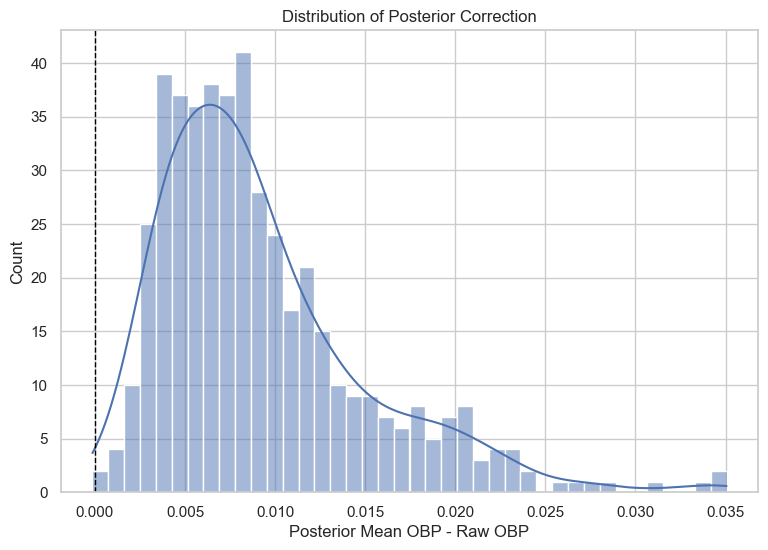

In [17]:
delta_df = posterior.dropna(subset=["obp_raw", "obp_posterior_mean"]).copy()
delta_df["posterior_minus_raw"] = delta_df["obp_posterior_mean"] - delta_df["obp_raw"]

plt.figure(figsize=(9, 6))
sns.histplot(delta_df["posterior_minus_raw"], bins=40, kde=True)
plt.axvline(0.0, linestyle="--", color="black", linewidth=1)
plt.title("Distribution of Posterior Correction")
plt.xlabel("Posterior Mean OBP - Raw OBP")
plt.ylabel("Count")
plt.show()

## 5) By-Season Posterior OBP Distribution

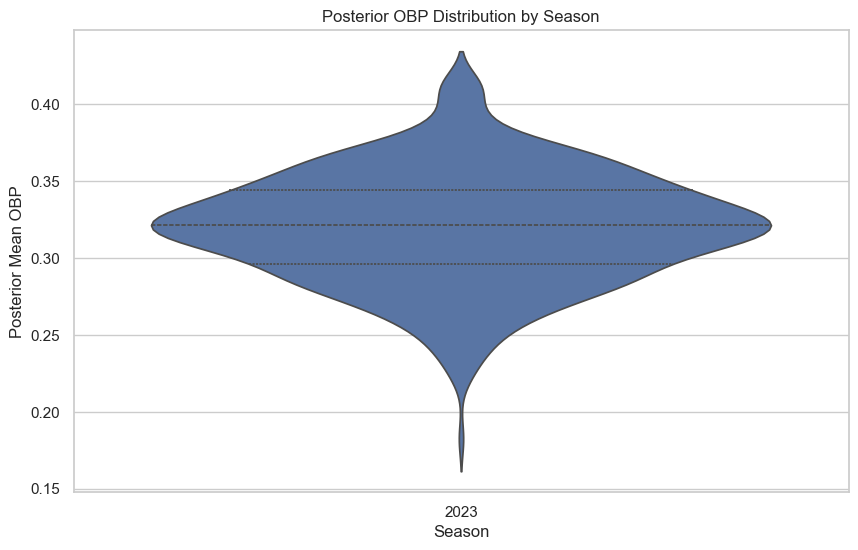

In [18]:
if "season" in posterior.columns:
    season_df = posterior.dropna(subset=["season", "obp_posterior_mean"]).copy()
    season_df["season"] = season_df["season"].astype(str)

    plt.figure(figsize=(10, 6))
    sns.violinplot(data=season_df, x="season", y="obp_posterior_mean", inner="quartile")
    plt.title("Posterior OBP Distribution by Season")
    plt.xlabel("Season")
    plt.ylabel("Posterior Mean OBP")
    plt.show()
else:
    print("No season column found in posterior output.")

## 6) Covariate Effects (Beta Forest Plot)

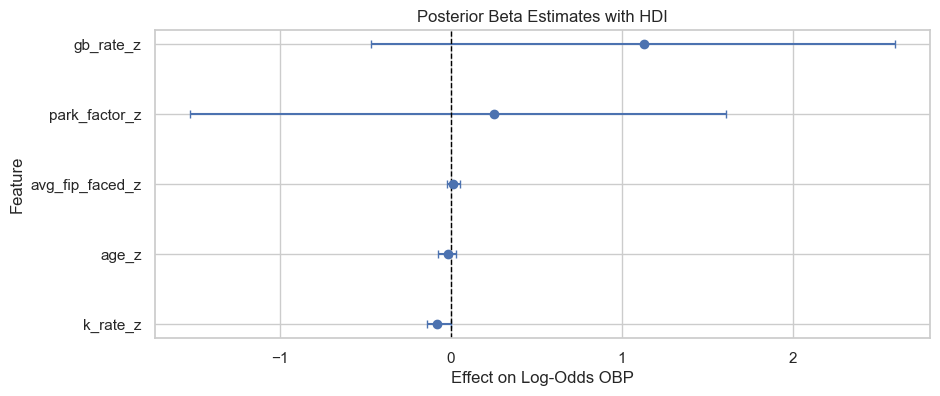

,feature,mean,sd,hdi_3%,hdi_97%,r_hat,ess_bulk
0,k_rate_z,-0.0810,0.0388,-0.1381,-0.0014,1.2938,5.9421
1,age_z,-0.0169,0.0315,-0.0727,0.0304,1.2726,6.4707
2,avg_fip_faced_z,0.0148,0.0236,-0.0229,0.0553,1.2473,6.9712
3,park_factor_z,0.2546,0.9885,-1.5259,1.6108,1.7282,3.5878
4,gb_rate_z,1.1334,0.9336,-0.4664,2.5985,1.5410,3.9767


In [19]:
b = beta.copy()
if "feature" not in b.columns:
    b["feature"] = b.get("index", pd.Series(range(len(b))).astype(str))

for col in ["mean", "hdi_3%", "hdi_97%"]:
    if col not in b.columns:
        raise ValueError(f"Missing required column in beta summary: {col}")

b = b.sort_values("mean", ascending=True)
x = b["mean"]
xerr = np.vstack([x - b["hdi_3%"], b["hdi_97%"] - x])

plt.figure(figsize=(10, max(4, 0.45 * len(b))))
plt.errorbar(x=x, y=b["feature"], xerr=xerr, fmt="o", capsize=3)
plt.axvline(0.0, linestyle="--", color="black", linewidth=1)
plt.title("Posterior Beta Estimates with HDI")
plt.xlabel("Effect on Log-Odds OBP")
plt.ylabel("Feature")
plt.show()

display_cols = [c for c in ["feature", "mean", "sd", "hdi_3%", "hdi_97%", "r_hat", "ess_bulk"] if c in b.columns]
b[display_cols].reset_index(drop=True)

## 7) Model Diagnostics Summary

In [20]:
diag_cols = [c for c in ["index", "mean", "sd", "r_hat", "ess_bulk", "ess_tail"] if c in model_summary.columns]
model_summary[diag_cols].head(20)

,index,mean,sd,r_hat,ess_bulk,ess_tail
0,beta[0],0.0148,0.0236,1.2473,6.9712,48.2844
1,beta[1],0.2546,0.9885,1.7282,3.5878,58.2298
2,beta[2],-0.0810,0.0388,1.2938,5.9421,32.9585
3,beta[3],1.1334,0.9336,1.5410,3.9767,41.7008
4,beta[4],-0.0169,0.0315,1.2726,6.4707,32.9585
5,tau,0.7700,0.1378,1.8571,3.2192,13.0913


## 8) Optional: ArviZ Trace Plots from NetCDF

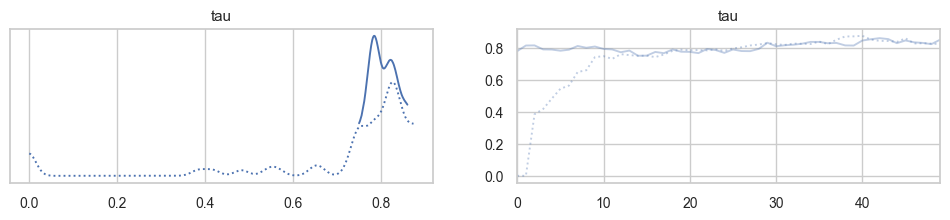

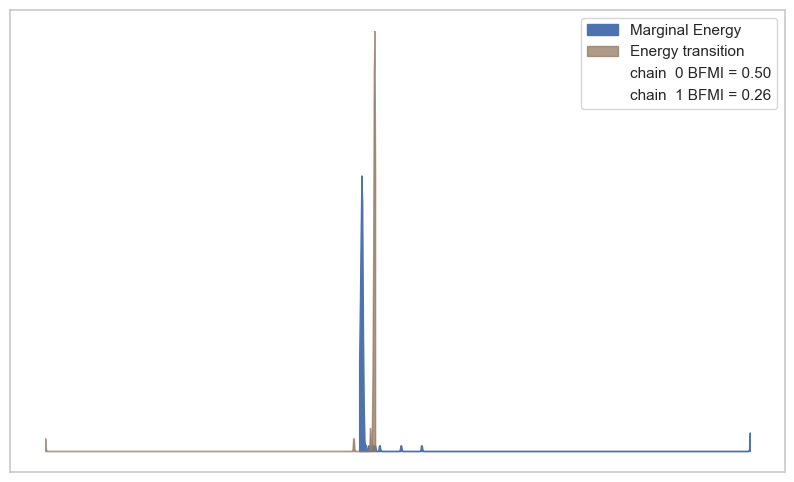

In [21]:
if az is None:
    print("ArviZ is not available. Install with: pip install arviz")
elif trace_path.exists():
    trace = az.from_netcdf(trace_path)
    az.plot_trace(trace, var_names=["tau"])
    plt.show()
    az.plot_energy(trace)
    plt.show()
else:
    print(f"Trace file not found: {trace_path}")